# Variables of the binomial multivariate metadata regression

### independet (explonatory, X) variables 
- Age -> continous numerical variable (age_group -> discrete numerical variable)
- Sex -> categorical variable (already as 1 and 2)
 - Site -> categorical variable (dummy variable needs to be added to map sites to numbers, SZC as reference group) (skip site for gemein)

#### dependent (response, Y) variable
- Label -> binary logical outcome (1 = target = pathology)

# Assumptions

* Independence of observations - problem with longitudinal patients
* Linearity of the logits
* No Multicollinearity - site x age are correlated
* No influential outliers - removed in previous step
* Big sample set (30+) - yes

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing.constants as c
import numpy as np

In [11]:
filename_1 = f'{c.BASE_DIR}/magisterka/metadata/ELM19_metadata_exams.csv'
filename_2 = f'{c.BASE_DIR}/magisterka/metadata/gemein_metadata_exams.csv'

In [12]:
df_1 = pd.read_csv(filename_1)
df_2 = pd.read_csv(filename_2)

In [13]:
df_1.drop(columns = 'age_group', inplace = True)
df_2.drop(columns = 'age_group', inplace = True)

In [14]:
df_1

,sub_id,exam_id,label,site,sex,age
0,sub-001,exam-001,0,TER_L,1,56.6
1,sub-002,exam-002,1,KLU,1,38
2,sub-003,exam-003,1,STG1,1,20.4
3,sub-004,exam-004,1,SRK,2,23.6
4,sub-005,exam-005,1,SZC,1,60.6
...,...,...,...,...,...,...
51044,sub-45863,exam-55783,1,Z04O,2,25
51045,sub-45864,exam-55784,0,Z04O,2,55
51046,sub-45865,exam-55785,1,Z04O,1,52
51047,sub-45866,exam-55786,1,Z04O,1,27.8


# Descriptive statistics and correlation

In [15]:
X, y = df_1[['site', 'sex', 'age']], df_1['label']

In [16]:
data = pd.concat([X, y], axis = 1)

In [17]:
sample_indices = np.linspace(0, len(X) - 8, 8, dtype = int) #endpoint=True default (including)
sample_indices = [ind for i in sample_indices for ind in range(i, i + 5)] #for each sample add 4 closest indices
sample_indices

[0,
 1,
 2,
 3,
 4,
 7291,
 7292,
 7293,
 7294,
 7295,
 14583,
 14584,
 14585,
 14586,
 14587,
 21874,
 21875,
 21876,
 21877,
 21878,
 29166,
 29167,
 29168,
 29169,
 29170,
 36457,
 36458,
 36459,
 36460,
 36461,
 43749,
 43750,
 43751,
 43752,
 43753,
 51041,
 51042,
 51043,
 51044,
 51045]

In [18]:
subdata = data.iloc[sample_indices, :] #choose only rows of that indices & all columns

In [19]:
styled = (
    subdata.style
    .set_properties(**{"text-align": "center"})
    .set_properties(
        **{"border-left": "5px solid red"},
        subset=["label"], #seperete the target column visually
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [("font-size", "13px")],
        },
        {
            "selector": "td",
            "props": [("font-size", "11px")],
        },
    ])
    .background_gradient()
    .format(precision=3)
)

styled

,site,sex,age,label
0,TER_L,1,56.600,0
1,KLU,1,38.000,1
2,STG1,1,20.400,1
3,SRK,2,23.600,1
4,SZC,1,60.600,1
7291,SZC,2,28.300,1
7292,SZC,2,36.600,1
7293,SZC,2,63.200,0
7294,SZC,2,59.700,0
7295,SZC,1,61.800,0


In [20]:
pd.set_option('float_format', '{:g}'.format)
data.describe()

,sex,age,label
count,51049,51049,51049
mean,1.52581,38.535,0.512233
std,0.499338,14.7453,0.499855
min,1,16,0
25%,1,25.2,0
50%,2,37.4,1
75%,2,51.9,1
max,2,65,1


In [21]:
numeric_data = data.drop(["sex", "site"], axis = 1)

In [24]:
numeric_data

,age,label
0,56.6,0
1,38,1
2,20.4,1
3,23.6,1
4,60.6,1
...,...,...
51044,25,1
51045,55,0
51046,52,1
51047,27.8,1


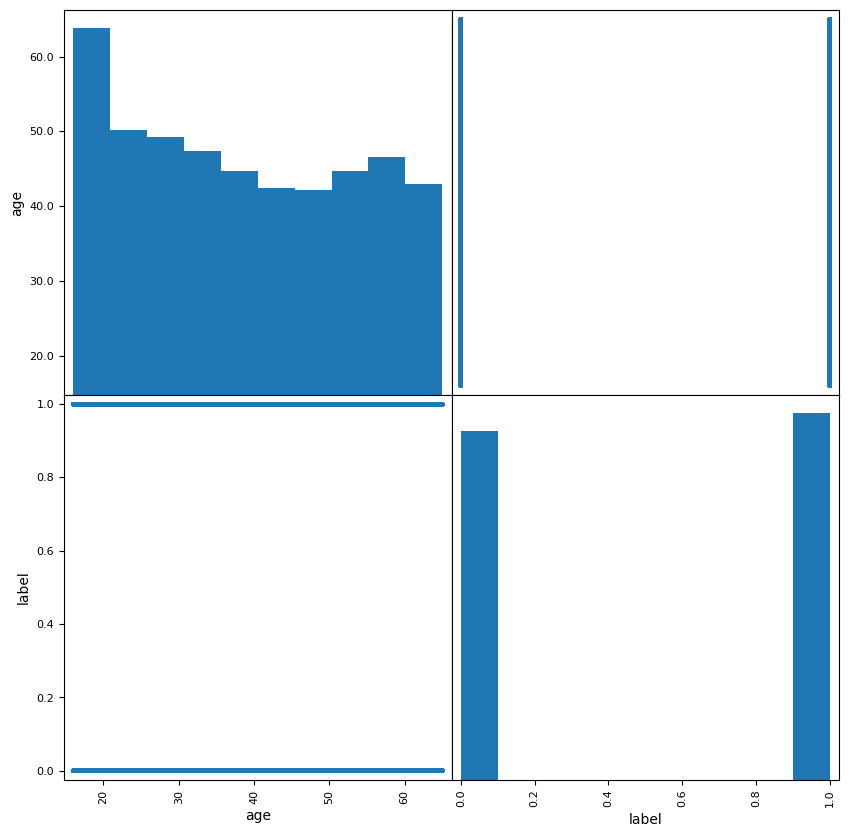

In [23]:
axes = pd.plotting.scatter_matrix(numeric_data, figsize = (10,10))
fixed_labels = [round(float(i.get_text()),2) for i in axes[0,0].get_yticklabels()]
_ = axes[0,0].set_yticklabels(fixed_labels)